MIT License

Copyright © 2023-2025 Tohoku University

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

In [1]:
from qklearn.linear_model import LinearRegression as QLR
from sklearn.linear_model import LinearRegression as SLR
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

Note: Please place `amplify-license.yaml` in the same directory as this notebook in advance.

In [ ]:
from amplify import FixstarsClient
from datetime import timedelta
from qklearn.utils import read_token

client = FixstarsClient()
client.token = read_token("Fixstars")
client.parameters.timeout = timedelta(milliseconds=1000)

In [3]:
# 回帰に使用するデータセットを生成
X, y = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    bias=0.0,
    noise=20.0)

# 訓練用データとテスト用データに分割
X_train, X_test = X[:80], X[-20:]
y_train, y_test = y[:80], y[-20:]

In [4]:
slr = SLR()
slr.fit(X_train, y_train)

# 作成したモデルから予測(学習用、検証用モデル使用)
y_train_pred_slr = slr.predict(X_train)
y_test_pred_slr = slr.predict(X_test)

MSE_sc = mean_squared_error(y_test, y_test_pred_slr)
print(MSE_sc)

219.4462581948324


k_min  9 , e_min  5 , MSE_min  214.37916136019444


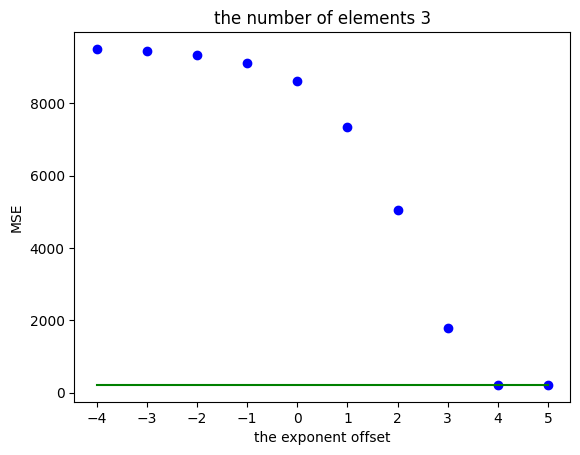

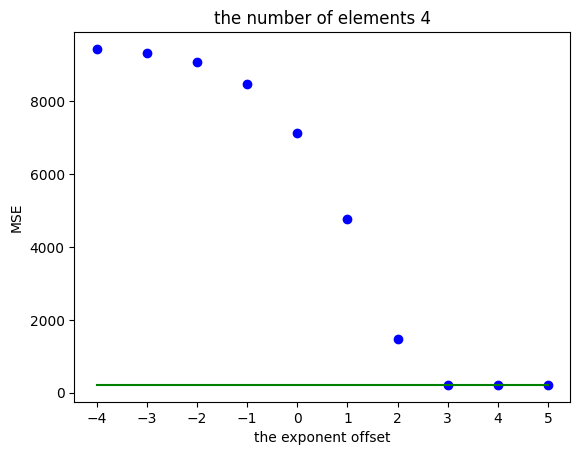

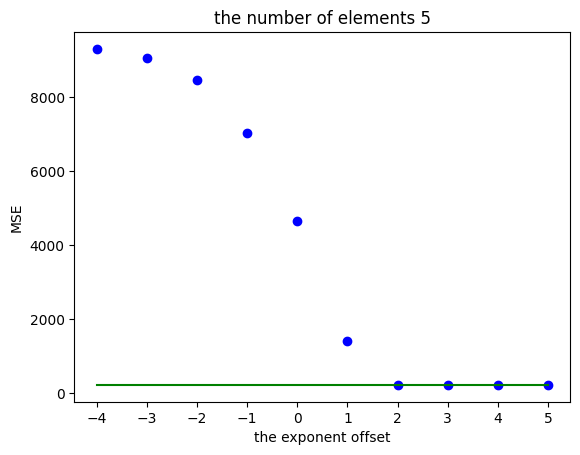

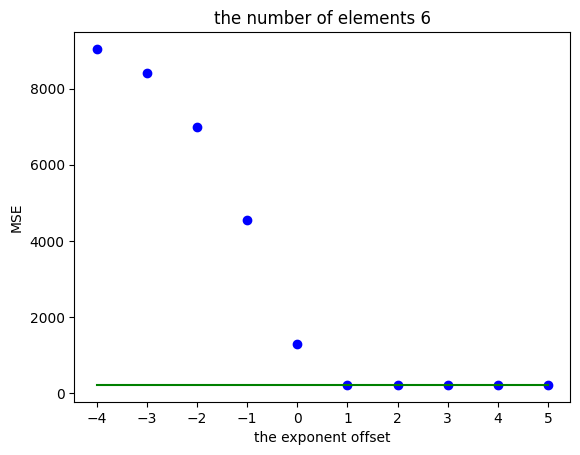

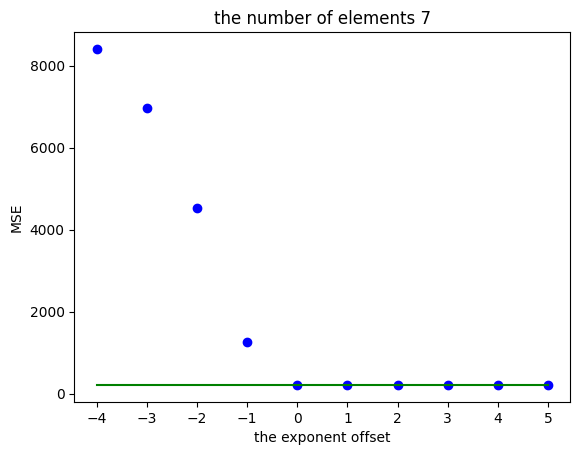

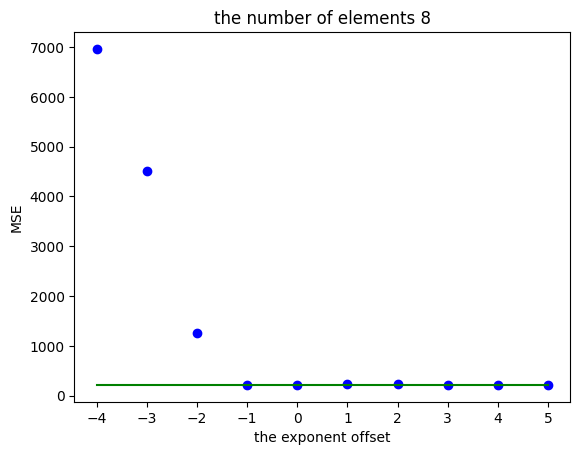

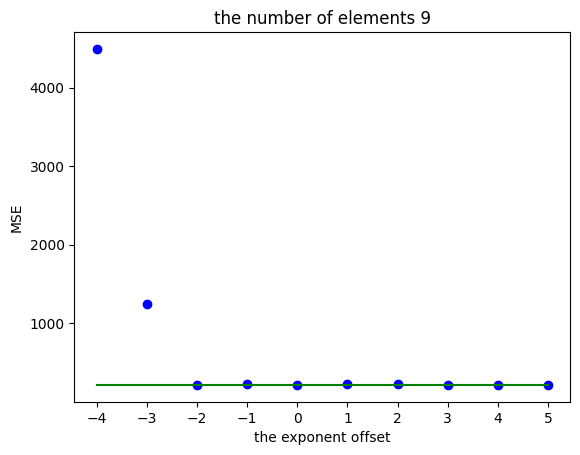

In [5]:
MSE_min = 10000
k_min = 0
e_min = 0

for k in range(3, 10):
  MSE = np.zeros(10)
  for i, e in enumerate([-4, -3, -2, -1, 0, 1, 2, 3, 4, 5]):
    model = QLR()
    model.fit(X_train, y_train, client, num_elements=k, exponent_offset=e)
    y_pred = model.predict(X_test)
    MSE[i] = mean_squared_error(y_test, y_pred)
    if MSE_min >= MSE[i]:
      MSE_min = MSE[i]
      k_min = k
      e_min = e

  fig = plt.figure()
  ax = fig.add_subplot(111)
  ax.set_title("the number of elements "+ str(k))
#   ax.set_ylim(0.4, 1)
  ax.set_xlabel("the exponent offset")
  ax.set_ylabel("MSE")
  ax.set_xticks([-4, -3, -2, -1, 0, 1, 2, 3, 4, 5])
  ax.scatter([-4, -3, -2, -1, 0, 1, 2, 3, 4, 5], MSE, c ='blue')
  ax.plot([-4, -3, -2, -1, 0, 1, 2, 3, 4, 5], np.full(10, MSE_sc), c='green')

print("k_min ", k_min, ", e_min ", e_min, ", MSE_min ", MSE_min)

In [7]:
qlr = QLR()
qlr.fit(X_train, y_train, client, num_elements=k_min, exponent_offset=e_min)

# 作成したモデルから予測(学習用、検証用モデル使用)
y_train_pred_qlr = qlr.predict(X_train)
y_test_pred_qlr = qlr.predict(X_test)

MSE = mean_squared_error(y_test, y_test_pred_qlr)
print(MSE)

214.37916136019444


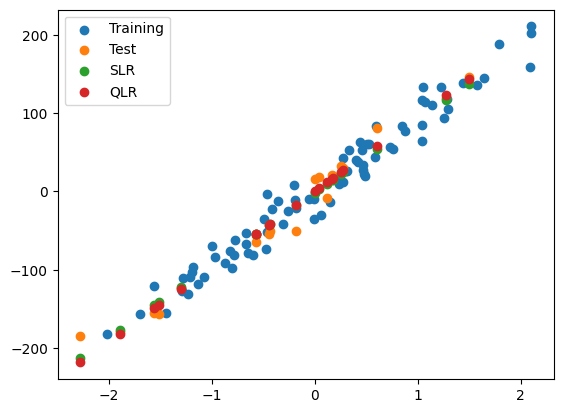

In [8]:
plt.scatter(X_train, y_train, label="Training")
plt.scatter(X_test, y_test, label="Test")
plt.scatter(X_test, y_test_pred_slr, label="SLR")
plt.scatter(X_test, y_test_pred_qlr, label="QLR")
plt.legend()

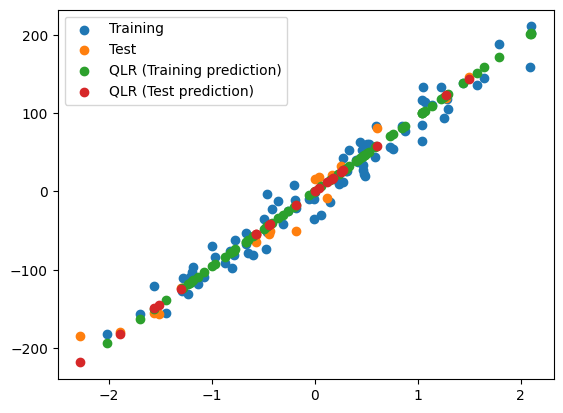

In [9]:
plt.scatter(X_train, y_train, label="Training")
plt.scatter(X_test, y_test, label="Test")
plt.scatter(X_train, y_train_pred_qlr, label="QLR (Training prediction)")
plt.scatter(X_test, y_test_pred_qlr, label="QLR (Test prediction)")
plt.legend()

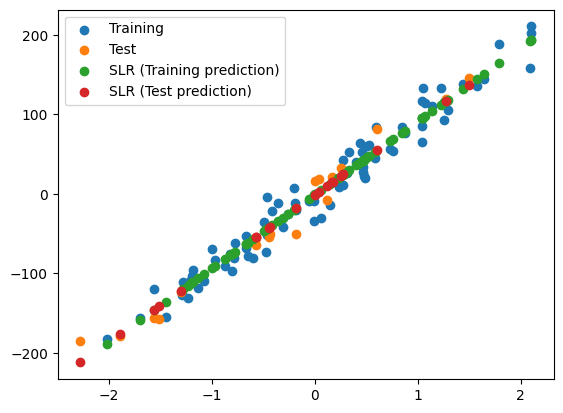

In [10]:
plt.scatter(X_train, y_train, label="Training")
plt.scatter(X_test, y_test, label="Test")
plt.scatter(X_train, y_train_pred_slr, label="SLR (Training prediction)")
plt.scatter(X_test, y_test_pred_slr, label="SLR (Test prediction)")
plt.legend()